In [1]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from feature_engine.outliers import Winsorizer

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import joblib

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv(r'C:\Users\Datasets\medical_insurance.csv')
df

,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# STEPS IN ML WORKFLOW : 

# 1. DATA CLEANING :

Real Industry Cleaning Order

In [3]:
def data_clean(df):
    
    return(
    
        df.
        
        rename(columns = lambda x : x.strip().upper())
        
        .drop_duplicates()
        
        .assign(
        
               GENDER = lambda _x : _x['GENDER'].str.strip().str.upper(),
               SMOKER = lambda _x : _x['SMOKER'].str.strip().str.upper(),
               REGION = lambda _x : _x['REGION'].str.strip().str.upper(),
            
        )
        
        .astype({
              
            "AGE": "int64",
            "CHILDREN": "int64",
            "BMI": "float64",
            "CHARGES": "float64"
        }
                
               
        )
        
    )

In [4]:
df = data_clean(df)

In [5]:
df

,AGE,GENDER,BMI,CHILDREN,SMOKER,REGION,CHARGES
0,19,FEMALE,27.900,0,YES,SOUTHWEST,16884.92400
1,18,MALE,33.770,1,NO,SOUTHEAST,1725.55230
2,28,MALE,33.000,3,NO,SOUTHEAST,4449.46200
3,33,MALE,22.705,0,NO,NORTHWEST,21984.47061
4,32,MALE,28.880,0,NO,NORTHWEST,3866.85520
...,...,...,...,...,...,...,...
1333,50,MALE,30.970,3,NO,NORTHWEST,10600.54830
1334,18,FEMALE,31.920,0,NO,NORTHEAST,2205.98080
1335,18,FEMALE,36.850,0,NO,SOUTHEAST,1629.83350
1336,21,FEMALE,25.800,0,NO,SOUTHWEST,2007.94500


# 2. EDA

In [6]:
def about_data(df):
    return (
    df.info(),
    df.describe(),
    df.shape,
    df.duplicated().sum(),
    df.isna().sum()
    )

In [7]:
about_data(df)

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   AGE       1337 non-null   int64  
 1   GENDER    1337 non-null   object 
 2   BMI       1337 non-null   float64
 3   CHILDREN  1337 non-null   int64  
 4   SMOKER    1337 non-null   object 
 5   REGION    1337 non-null   object 
 6   CHARGES   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB


(None,
                AGE          BMI     CHILDREN       CHARGES
 count  1337.000000  1337.000000  1337.000000   1337.000000
 mean     39.222139    30.663452     1.095737  13279.121487
 std      14.044333     6.100468     1.205571  12110.359656
 min      18.000000    15.960000     0.000000   1121.873900
 25%      27.000000    26.290000     0.000000   4746.344000
 50%      39.000000    30.400000     1.000000   9386.161300
 75%      51.000000    34.700000     2.000000  16657.717450
 max      64.000000    53.130000     5.000000  63770.428010,
 (1337, 7),
 0,
 AGE         0
 GENDER      0
 BMI         0
 CHILDREN    0
 SMOKER      0
 REGION      0
 CHARGES     0
 dtype: int64)

Distribution of target column:

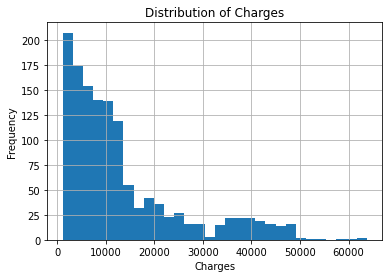

In [8]:
import matplotlib.pyplot as plt

df["CHARGES"].hist(bins=30)

plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.title("Distribution of Charges")

plt.show()

Check numericals feat:

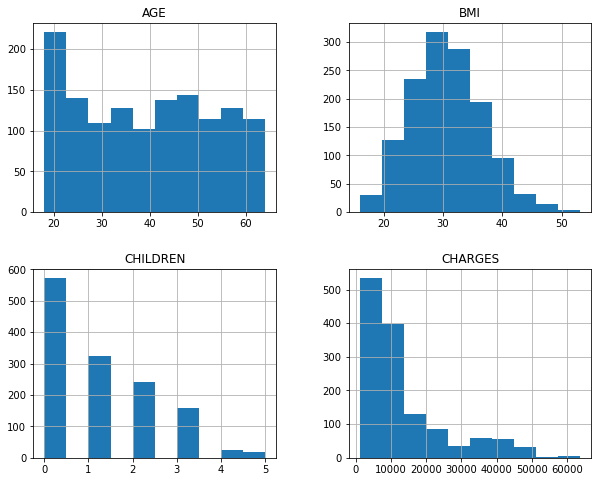

In [9]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

df[num_cols].hist(figsize=(10,8))

plt.show()

In [10]:
corr = df.corr(numeric_only=True)

print(corr)

               AGE       BMI  CHILDREN   CHARGES
AGE       1.000000  0.109344  0.041536  0.298308
BMI       0.109344  1.000000  0.012755  0.198401
CHILDREN  0.041536  0.012755  1.000000  0.067389
CHARGES   0.298308  0.198401  0.067389  1.000000


Analyze Categorical Features

In [11]:
def analyze_cat_feat(df):
    
    return (
    
        df.GENDER.value_counts(),
        
        df.SMOKER.value_counts(),
        
        df.REGION.value_counts()
        
    )

In [12]:
analyze_cat_feat(df)

(GENDER
 MALE      675
 FEMALE    662
 Name: count, dtype: int64,
 SMOKER
 NO     1063
 YES     274
 Name: count, dtype: int64,
 REGION
 SOUTHEAST    364
 SOUTHWEST    325
 NORTHWEST    324
 NORTHEAST    324
 Name: count, dtype: int64)

Relationship with Target

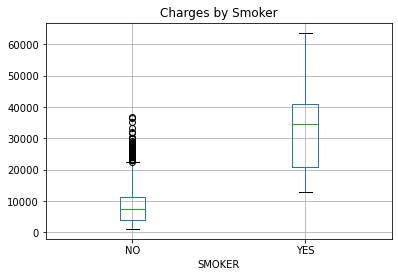

In [13]:
# Charges vs Smoker

import matplotlib.pyplot as plt

df.boxplot(column="CHARGES", by="SMOKER")

plt.title("Charges by Smoker")
plt.suptitle("")

plt.show()

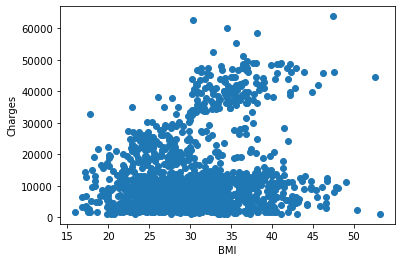

In [14]:
# Charges vs BMI

plt.scatter(df["BMI"], df["CHARGES"])

plt.xlabel("BMI")
plt.ylabel("Charges")

plt.show()

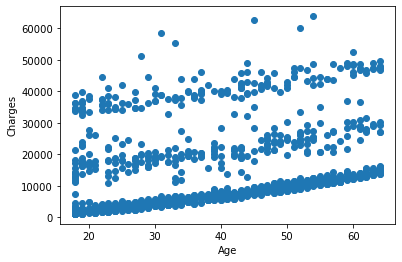

In [15]:
# Charges vs Age

plt.scatter(df["AGE"], df["CHARGES"])

plt.xlabel("Age")
plt.ylabel("Charges")

plt.show()

Detect outliers :

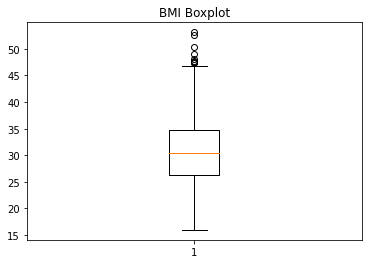

In [16]:
import matplotlib.pyplot as plt

plt.boxplot(df["BMI"])

plt.title("BMI Boxplot")

plt.show()

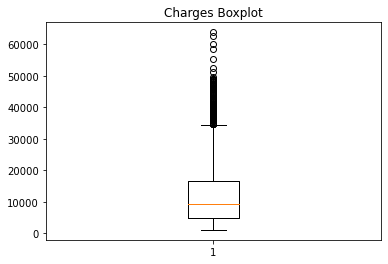

In [17]:
plt.boxplot(df["CHARGES"])

plt.title("Charges Boxplot")

plt.show()

# 3. Train-Test Split

In [18]:
X = df.drop("CHARGES", axis=1)

y = df["CHARGES"]

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(1069, 6)
(268, 6)
(1069,)
(268,)


NOTE : VERY IMPORTANT
    
From NOW ON: All preprocessing must learn ONLY from: X_train
        
NOT full dataset.

4. Preprocessing

Numerical Pipeline with Outlier Capping

In [21]:
num_cols = ["AGE", "BMI", "CHILDREN"]

cat_cols = ["GENDER", "SMOKER", "REGION"]

In [22]:
num_pipeline = Pipeline([

    # cap outliers
    ("winsorizer",Winsorizer(capping_method="iqr",tail="both",fold=1.5)),

    # impute missing values
    ("imputer",SimpleImputer(strategy="median")),

    # scale features
    ("scaler",StandardScaler())
])

In [23]:
num_pipeline

Pipeline(steps=[('winsorizer',
                 Winsorizer(capping_method='iqr', fold=1.5, tail='both')),
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

Categorical Pipeline

In [24]:
cat_pipeline = Pipeline([

    ("imputer",SimpleImputer(strategy="most_frequent")),

    ("encoder",OneHotEncoder(handle_unknown="ignore"))
])

In [25]:
cat_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])

Combine Pipelines

In [26]:
preprocessor = ColumnTransformer([

    ("num", num_pipeline, num_cols),

    ("cat", cat_pipeline, cat_cols)
])

In [27]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('winsorizer',
                                                  Winsorizer(capping_method='iqr',
                                                             fold=1.5,
                                                             tail='both')),
                                                 ('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['AGE', 'BMI', 'CHILDREN']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['GENDER', 'SMOKER', 'REGION'])])

In [28]:
X_train_processed = preprocessor.fit_transform(X_train)

In [29]:
X_train_processed

array([[-1.1576804 , -1.00330457, -0.90790804, ...,  0.        ,
         0.        ,  0.        ],
       [-1.30061876, -0.797207  ,  0.7669042 , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.91492586,  1.16864674,  0.7669042 , ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [-1.37208794, -1.42217493, -0.07050192, ...,  0.        ,
         0.        ,  1.        ],
       [-0.08564268, -0.4208912 ,  1.60431032, ...,  0.        ,
         0.        ,  1.        ],
       [-0.30005022,  0.8907905 ,  0.7669042 , ...,  0.        ,
         1.        ,  0.        ]])

In [30]:
X_test_processed = preprocessor.transform(X_test)

In [31]:
X_test_processed

array([[ 0.70051832, -1.33623141, -0.90790804, ...,  0.        ,
         0.        ,  0.        ],
       [-0.72886531, -0.82140469,  2.44171645, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.84345668,  0.97840283,  1.60431032, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [-1.22914958,  0.6771833 ,  0.7669042 , ...,  0.        ,
         0.        ,  0.        ],
       [ 1.5581485 ,  0.96421797, -0.07050192, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.55757996, -1.03501189, -0.90790804, ...,  0.        ,
         0.        ,  0.        ]])

preprocessing + model pipeline (baseline model)

In [32]:
model_pipeline = Pipeline([

    ("preprocessing", preprocessor),

    ("model", LinearRegression())
])

In [33]:
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('winsorizer',
                                                                   Winsorizer(capping_method='iqr',
                                                                              fold=1.5,
                                                                              tail='both')),
                                                                  ('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['AGE', 'BMI', 'CHILDREN']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['GENDER', 'SMOKER',
                                                   'REGION'])])),
                ('model', LinearRegression())])

Make Predictions

In [34]:
y_pred = model_pipeline.predict(X_test)

In [35]:
y_pred

array([ 8.11991146e+03,  5.71407782e+03,  1.43816020e+04,  3.17720527e+04,
        9.01027845e+03,  1.31846671e+04,  3.04808191e+04,  1.43629958e+03,
        1.06569486e+04,  1.13117272e+04,  1.03317657e+04,  3.31123734e+04,
        3.11055898e+04,  1.74495618e+04,  1.08324339e+04,  9.52173406e+03,
        4.18545571e+03,  3.17687510e+04,  3.20320266e+03,  5.23815547e+03,
        3.57768349e+03,  3.02885349e+04,  1.49448019e+04,  3.04555958e+04,
        3.11342002e+04,  5.53149655e+03,  3.55461424e+04,  3.65770347e+04,
        1.14094558e+04,  1.42253164e+04,  6.51197738e+03,  1.27592478e+04,
        3.98776327e+02,  1.20710142e+04,  3.95313806e+04,  1.23431885e+04,
        4.73606205e+03,  3.87960672e+03,  3.08359508e+04,  8.95199720e+03,
        7.10176483e+03,  3.00723626e+04,  3.48132182e+04,  1.23023898e+04,
        7.31127735e+03,  3.40616255e+03,  6.26425154e+03,  8.97489035e+03,
        4.25220816e+03,  9.04041261e+03,  6.62148278e+03,  1.21388388e+04,
        3.12263854e+04,  

Evaluation

In [38]:
mae1 = mean_absolute_error(y_test, y_pred)

mse1 = mean_squared_error(y_test, y_pred)

rmse1 = mse1 ** 0.5

r21 = r2_score(y_test, y_pred)

In [39]:
print("MAE :", mae1)

print("MSE :", mse1)

print("RMSE :", rmse1)

print("R2 Score :", r21)

MAE : 4183.711578096274
MSE : 35480564.972920775
RMSE : 5956.5564693806755
R2 Score : 0.8069148620587286


Visual Evaluation

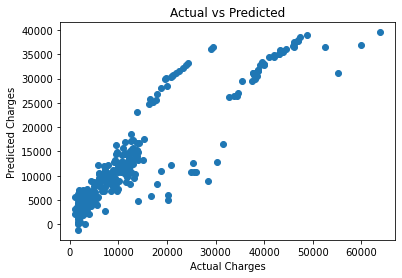

In [40]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")

plt.title("Actual vs Predicted")

plt.show()

Residual Analysis

In [41]:
residuals = y_test - y_pred

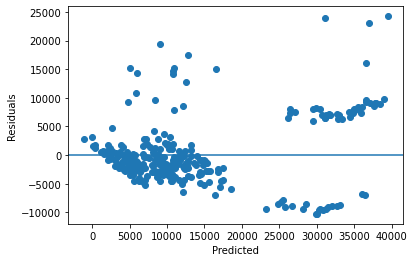

In [42]:
plt.scatter(y_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted")
plt.ylabel("Residuals")

plt.show()

preprocessing + model pipeline (improved model)

In [43]:
rf_pipeline = Pipeline([

    ("preprocessing", preprocessor),

    ("model",
     RandomForestRegressor(
         n_estimators=50,
         random_state=42
     ))
])

In [69]:
rf_pipeline

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('winsorizer',
                                                                   Winsorizer(capping_method='iqr',
                                                                              fold=1.5,
                                                                              tail='both')),
                                                                  ('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['AGE', 'BMI', 'CHILDREN']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['GENDER', 'SMOKER',
                                                   'REGION'])])),
                ('model',
                 RandomForestRegressor(n_estimators=50, random_state=42))])

In [44]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('winsorizer',
                                                                   Winsorizer(capping_method='iqr',
                                                                              fold=1.5,
                                                                              tail='both')),
                                                                  ('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['AGE', 'BMI', 'CHILDREN']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['GENDER', 'SMOKER',
                                                   'REGION'])])),
                ('model',
                 RandomForestRegressor(n_estimators=50, random_state=42))])

Make Predictions

In [45]:
rf_pred = rf_pipeline.predict(X_test)

In [46]:
rf_pred

array([10237.8765854,  6536.7225958, 11578.5689232, 42556.3910888,
        6546.6034788,  9169.459527 , 39945.5540678,  2183.583121 ,
        8873.994604 , 11140.4792692, 14004.4118006, 24340.1840404,
       42654.102361 , 15412.7765948,  7351.639631 ,  8689.4711462,
       12385.5619696, 39722.4032274,  4936.9006172,  5397.3232446,
       10390.1743302, 20978.3841156,  9720.1998072, 21175.7176932,
       38427.3890744, 16670.2728208, 42178.9324586, 45958.969923 ,
       10915.1112842, 13009.5381796,  4535.5647774,  9114.101524 ,
        2750.1833244, 15205.5498396, 47871.557458 ,  9689.490561 ,
        8197.2105092,  5895.4786332, 22642.8138664,  9150.8360202,
        3100.607295 , 21347.0956136, 42026.6022166,  9415.369884 ,
        8896.7356468,  3295.223656 ,  3397.125053 ,  8106.5673348,
        5851.320504 , 14064.8397984,  5430.129265 , 10975.0781806,
       21629.8058194,  5918.2802254,  7342.386052 ,  9310.8594718,
       11672.9618452,  6472.00061  , 40594.1337704,  7380.0097

Evaluate Model

In [48]:
mae2 = mean_absolute_error(y_test, rf_pred)

mse2 = mean_squared_error(y_test, rf_pred)

rmse2 = mse2 ** 0.5

r22 = r2_score(y_test, rf_pred)

In [49]:
print("MAE :", mae2)

print("MSE :", mse2)

print("RMSE :", rmse2)

print("R2 Score :", r22)

MAE : 2628.0007246589553
MSE : 22335152.54034097
RMSE : 4726.008097786224
R2 Score : 0.8784521607115756


# Compare both model

In [50]:
model_comparison = {

    "LR_model": {
        "MAE": mae1,
        "MSE": mse1,
        "RMSE": rmse1,
        "R2 Score": r21
    },

    "RF_model": {
        "MAE": mae2,
        "MSE": mse2,
        "RMSE": rmse2,
        "R2 Score": r22
    }
}

In [51]:
pd.DataFrame(model_comparison)

,LR_model,RF_model
MAE,4.183712e+03,2.628001e+03
MSE,3.548056e+07,2.233515e+07
RMSE,5.956556e+03,4.726008e+03
R2 Score,8.069149e-01,8.784522e-01


Feature IMP

In [52]:
rf_model = rf_pipeline.named_steps["model"]

In [53]:
rf_model

RandomForestRegressor(n_estimators=50, random_state=42)

In [54]:
importances = rf_model.feature_importances_

In [55]:
importances

array([0.13633901, 0.21372032, 0.02302923, 0.00437317, 0.00444532,
       0.46736629, 0.13056967, 0.00510219, 0.00581613, 0.00537311,
       0.00386556])

In [56]:
feature_names = rf_pipeline.named_steps[
    "preprocessing"
].get_feature_names_out()

In [57]:
feature_names

array(['num__AGE', 'num__BMI', 'num__CHILDREN', 'cat__GENDER_FEMALE',
       'cat__GENDER_MALE', 'cat__SMOKER_NO', 'cat__SMOKER_YES',
       'cat__REGION_NORTHEAST', 'cat__REGION_NORTHWEST',
       'cat__REGION_SOUTHEAST', 'cat__REGION_SOUTHWEST'], dtype=object)

In [58]:
import pandas as pd

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

In [59]:
feature_importance_df

,feature,importance
0,num__AGE,0.136339
1,num__BMI,0.213720
2,num__CHILDREN,0.023029
3,cat__GENDER_FEMALE,0.004373
4,cat__GENDER_MALE,0.004445
5,cat__SMOKER_NO,0.467366
6,cat__SMOKER_YES,0.130570
7,cat__REGION_NORTHEAST,0.005102
8,cat__REGION_NORTHWEST,0.005816
9,cat__REGION_SOUTHEAST,0.005373


In [60]:
feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)

In [61]:
print(feature_importance_df)

                  feature  importance
5          cat__SMOKER_NO    0.467366
1                num__BMI    0.213720
0                num__AGE    0.136339
6         cat__SMOKER_YES    0.130570
2           num__CHILDREN    0.023029
8   cat__REGION_NORTHWEST    0.005816
9   cat__REGION_SOUTHEAST    0.005373
7   cat__REGION_NORTHEAST    0.005102
4        cat__GENDER_MALE    0.004445
3      cat__GENDER_FEMALE    0.004373
10  cat__REGION_SOUTHWEST    0.003866


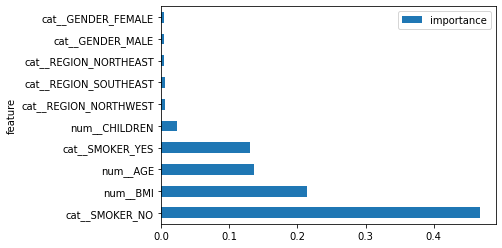

In [62]:
import matplotlib.pyplot as plt

feature_importance_df.head(10).plot(
    x="feature",
    y="importance",
    kind="barh"
)

plt.show()

# Mlflow tracking

In [63]:
import mlflow
import mlflow.sklearn

In [67]:
mlflow.is_tracking_uri_set()

True

In [68]:
# set the ml flow tracking server
mlflow.set_tracking_uri(uri="http://127.0.0.1:5000")

# set the experiment name
mlflow.set_experiment('MLflow RF_model_tracking')

# track the model training with a run
with mlflow.start_run(run_name='seven') as run:
    
    #log input and output as a data signature 
    signature = mlflow.models.infer_signature(model_input=X_train,model_output=rf_pipeline.predict(X_train))
    
    # log the hyperparameters of the model
    mlflow.log_params(rf_pipeline.get_params())
    
    # log the accuracy score
    mlflow.log_metric(key='mae2',value=mae2)
    mlflow.log_metric(key='mse2',value=mse2)
    mlflow.log_metric(key='rmse2',value=rmse2)
    mlflow.log_metric(key='r22',value=r22)
    
    # log the model
    mlflow.sklearn.log_model(sk_model=rf_pipeline, artifact_path='models',signature=signature)
    
    # log dataset 
    # dataset tracking
    dataset = mlflow.data.from_pandas(df,source="insurance.csv",name="insurance_dataset")

    mlflow.log_input(dataset, context="training")
    
    # set the tag for run
    mlflow.set_tag(key='RF_model_tracking_metrics',value='Random Forest model trained on insurance data')



C:\Users\Sanket\AppData\Roaming\Python\Python39\site-packages\mlflow\models\signature.py:144: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  inputs = _infer_schema(model_input)
C:\Users\Sanket\AppData\Roaming\Python\Python39\site-packages\mlflow\data\dataset_source_registry.py:142: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDa

# MLFLOW TRACKING FOR HYPERPARAMETER TUNNING

In [72]:
from sklearn.model_selection import GridSearchCV

In [77]:
# set the uri for server

mlflow.set_tracking_uri("http://127.0.0.1:8080")

mlflow.set_experiment("Grid Search")

mlflow.sklearn.autolog() # it is use for auto log all the para of every combinations that gridsearchcv make

params_grid = {
    "model__n_estimators": list(range(100,300,100)),
    "model__max_depth": [2,3,4,5]
}

with mlflow.start_run(run_name='outer',nested=True) as parent:
    # grid search object
    grid_search = GridSearchCV(estimator=rf_pipeline,
                               cv=3,
                               param_grid=params_grid,
                               scoring='r2',
                               n_jobs=-1)
    # fit the grid search
    grid_search.fit(X_train,y_train)

with mlflow.start_run(run_name='best_model') as best:
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_metric("r22",grid_search.best_score_)
    mlflow.sklearn.log_model(sk_model=grid_search.best_estimator_,
                            artifact_path='best_model',
                            registered_model_name='insurance_random_forest')


2026/05/11 14:40:22 WARNING mlflow.utils.autologging_utils: You are using an unsupported version of sklearn. If you encounter errors during autologging, try upgrading / downgrading sklearn to a supported version, or try upgrading MLflow.
2026/05/11 14:40:22 WARNING mlflow.utils: Truncated the value of the key `estimator`. Truncated value: `Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('winsorizer',
                                                                   Winsorizer(capping_method='iqr',
                                                                              fold=1.5,
                                                                              tail='both')),
                                            ...`
2026/05/11 14:40:22 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\Sanket\AppData\Roaming\Python\Python39\site-

2026/05/11 14:40:37 WARNING mlflow.utils: Truncated the value of the key `preprocessing`. Truncated value: `ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('winsorizer',
                                                  Winsorizer(capping_method='iqr',
                                                             fold=1.5,
                                                             tail='both')),
                                                 ('imputer',
                                                  SimpleImputer(strategy='median')),
                 ...`
Registered model 'insurance_random_forest' already exists. Creating a new version of this model...
2026/05/11 14:40:41 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation. Model name: insurance_random_forest, version 4
Created version '4' of model 'insurance_random_forest'.
